In [1]:
import json
import pandas as pd
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from zoneinfo import ZoneInfo
from glob import glob
from pathlib import Path

# Trio Dataset

In [2]:

from Scripts.insulin_trace import (
    clean_insulin_data,
    process_insulin_data
)

from Scripts.glucose_trace import (
    process_glucose_data
)

from Scripts.extract_user_profile import (
    extract_user_profile,
    save_extracted_data
) 

FOLDER_PATH = "/Users/ziqiangzhu/TrioOrefCLI/trio_dataset/trio-oref-validation/algorithm-comparisons"

In [3]:
def cut_into_chunks(sorted_df, large_gap = pd.Timedelta(minutes=30)):
    time_diffs = sorted_df["date"].diff()

    is_large_gap = time_diffs > large_gap

    sorted_df['chunk_id'] = is_large_gap.cumsum()

    chunks = [group for _, group in sorted_df.groupby('chunk_id')]

    print(f"Chopped into {len(chunks)} chunks")

    # clean up
    for chunk in chunks:
        chunk.drop(columns=['chunk_id'], inplace=True)

    return chunks

In [ ]:
def pair_chunk_to(chunk: pd.DataFrame, candidate_chunks: list[pd.DataFrame]):
    chunk_start = chunk["date"].min()
    chunk_end = chunk["date"].max()

    if chunk_end - chunk_start < pd.Timedelta(hours=1):
        print("Not worth pairing, chunk shorter than 1 hour")
        return None    

    best_match = None
    best_overlap = pd.Timedelta(0)

    for candidate in candidate_chunks:
        candidate_start = candidate["date"].min()
        candidate_end = candidate["date"].max()

        latest_start = max(chunk_start, candidate_start)
        earliest_end = min(chunk_end, candidate_end)

        overlap = max(pd.Timedelta(0), earliest_end - latest_start)

        if overlap > best_overlap:
            best_overlap = overlap
            best_match = candidate[candidate["date"].between(latest_start, earliest_end)]

    return best_match

## Data Structure


All we are looking is the timestamped insulin amount from PumpHistoryEvent (amount property) and timestamped glucose amount from BloodGlucose (glucose property).

```Swift
struct PumpHistoryEvent: JSON, Equatable, Identifiable {
    let id: String
    let type: EventType
    let timestamp: Date
    let amount: Decimal?
    let duration: Int?
    let durationMin: Int?
    let rate: Decimal?
    let temp: TempType?
    let carbInput: Int?
    let fatInput: Int?
    let proteinInput: Int?
    let note: String?
    let isSMB: Bool?
    let isExternal: Bool?
    let isExternalInsulin: Bool?

    init(
        id: String,
        type: EventType,
        timestamp: Date,
        amount: Decimal? = nil,
        duration: Int? = nil,
        durationMin: Int? = nil,
        rate: Decimal? = nil,
        temp: TempType? = nil,
        carbInput: Int? = nil,
        fatInput: Int? = nil,
        proteinInput: Int? = nil,
        note: String? = nil,
        isSMB: Bool? = nil,
        isExternal: Bool? = nil,
        isExternalInsulin: Bool? = nil
    ) {
        self.id = id
        self.type = type
        self.timestamp = timestamp
        self.amount = amount
        self.duration = duration
        self.durationMin = durationMin
        self.rate = rate
        self.temp = temp
        self.carbInput = carbInput
        self.fatInput = fatInput
        self.proteinInput = proteinInput
        self.note = note
        self.isSMB = isSMB
        self.isExternal = isExternal
        self.isExternalInsulin = isExternalInsulin
    }
}

struct BloodGlucose: JSON, Identifiable, Hashable, Codable {
    enum Direction: String, JSON {
        case tripleUp = "TripleUp"
        case doubleUp = "DoubleUp"
        case singleUp = "SingleUp"
        case fortyFiveUp = "FortyFiveUp"
        case flat = "Flat"
        case fortyFiveDown = "FortyFiveDown"
        case singleDown = "SingleDown"
        case doubleDown = "DoubleDown"
        case tripleDown = "TripleDown"
        case none = "NONE"
        case notComputable = "NOT COMPUTABLE"
        case rateOutOfRange = "RATE OUT OF RANGE"

        ...
    }

    enum CodingKeys: String, CodingKey {
        case _id
        case idKey = "id"
        case sgv
        case direction
        case date
        case dateString
        case unfiltered
        case filtered
        case noise
        case glucose
        case type
        case activationDate
        case sessionStartDate
        case transmitterID

        ...
    }

    ...
    
    var _id: String?

    // this is a dummy property, we never set it. We have it for more flexible
    // glucose record parsing (see the `init(from decoder: Decoder)` method)
    var idKey: String?

    var sgv: Int?
    var direction: Direction?
    let date: Decimal
    let dateString: Date
    let unfiltered: Decimal?
    let filtered: Decimal?
    let noise: Int?
    var glucose: Int?
    var type: String? = nil
    var activationDate: Date? = nil
    var sessionStartDate: Date? = nil
    var transmitterID: String? = nil
    var isStateValid: Bool { sgv ?? 0 >= 39 && noise ?? 1 != 4 }

    ...
}
```

Raw json is coming from
```swift
enum JSONCompare {
    static let log = try? JsSwiftOrefComparisonLogger()
    static func logDifferences(
        function: OrefFunction,
        swift: OrefFunctionResult,
        swiftDuration: TimeInterval,
        javascript: OrefFunctionResult,
        javascriptDuration: TimeInterval,
        iobInputs: IobInputs? = nil,
        mealInputs: MealInputs? = nil,
        autosensInputs: AutosensInputs? = nil,
        determineBasalInputs: DetermineBasalInputs? = nil
    ) {
        let comparison = createComparison(
            function: function,
            swift: swift,
            swiftDuration: swiftDuration,
            javascript: javascript,
            javascriptDuration: javascriptDuration,
            iobInputs: iobInputs,
            mealInputs: mealInputs,
            autosensInputs: autosensInputs,
            determineBasalInputs: determineBasalInputs
        )

        Task {
            do {
                try await log?.logComparison(comparison: comparison)
            } catch {
                warning(.openAPS, "logComparison exception: \(error)", error: error)
            }
        }
    }
}
```

## Get insulin & glucose trace

### Single Json

In [2]:
JSON_PATH = "/Users/ziqiangzhu/TrioOrefCLI/trio_dataset/trio-oref-validation/algorithm-comparisons/2025-07-31/0.5.1/meal/70431AA7-98C0-4ED9-8EAB-93530905061B/0a6c019b-8d12-4541-bec0-7d9c5196862c.json"

with open(JSON_PATH) as f:
    data = json.load(f)

insulin_df = clean_insulin_data(data)
insulin_df = process_insulin_data(insulin_df)
display(insulin_df)

,date,type,unit,value,deliveryReason
0,2025-07-30 02:31:57.750999928+00:00,insulin,U,4.0,bolus
1,2025-07-30 02:37:06.102999926+00:00,insulin,U,0.0,basal
2,2025-07-30 02:46:58.059999943+00:00,insulin,U,0.0,basal
3,2025-07-30 02:56:58.605000019+00:00,insulin,U,0.0,basal
4,2025-07-30 03:07:01.321000099+00:00,insulin,U,0.0,basal
...,...,...,...,...,...
249,2025-07-31 02:12:01.006999969+00:00,insulin,U,0.25,bolus
250,2025-07-31 02:16:58.040999889+00:00,insulin,U,0.2,bolus
251,2025-07-31 02:21:58.509000063+00:00,insulin,U,0.2,bolus
252,2025-07-31 02:27:05.081000090+00:00,insulin,U,0.2,bolus


In [3]:
# insulin_df["date"] = insulin_df["date"].dt.strftime("%Y-%m-%dT%H:%M:%SZ")
# insulin_df.to_json(
#     "insulin_one.json",
#     orient="records",
#     indent=2,
# )

### For multiple json

In [90]:

LAST_FOLDER = "meal/70431AA7-98C0-4ED9-8EAB-93530905061B" # Sam's 

# LAST_FOLDER = "meal/0A9CA9B2-CD18-4AF4-8384-866278470D72"

# LAST_FOLDER = "meal/547C7B4D-D130-4A57-AFF9-C6F23D577308"

# LAST_FOLDER = "meal/681E14FF-BD54-4DFA-9C67-88A54B793F28" # not usable

# LAST_FOLDER = "meal/14CFC51D-9B72-4B05-93BC-3544FCA8D58B"

# LAST_FOLDER = "meal/673C17FA-4728-467E-9331-72EAE8FC04B4" # not usable 

# LAST_FOLDER = "meal/77F59FB6-ED9C-4989-AA86-F00FC1EAC1B1"

# LAST_FOLDER = "meal/9371E304-BC2B-49D1-91AB-C1CC82801ACF"

# LAST_FOLDER = "meal/AB00357B-DD41-4CBB-83FE-C9A43A49D34A"

# LAST_FOLDER = "meal/F349A9CB-640F-4D82-BD2E-B5089F254135"

# example folder path: downloaded_files/trio-oref-validation/algorithm-comparisons/2025-07-27/0.5.1/meal/70431AA7-98C0-4ED9-8EAB-93530905061B

Load all the json from `FOLDER_PATH/**/LAST_FOLDER/*.json` and extract the timestamped insulin and glucose like above. End result should be two dataFrames, one for insulin and one for glucose.

In [91]:
json_files = sorted(glob(f"{FOLDER_PATH}/**/{LAST_FOLDER}/*.json", recursive=True))
print(f"Found {len(json_files)} JSON files")


Found 3493 JSON files


In [92]:
# glucose trace
glucose_list = []
insulin_list = []

for i, jf in enumerate(json_files):
    try:
        with open(jf) as f:
            data = json.load(f)

        insulin_df = clean_insulin_data(data)
        glucose_df = process_glucose_data(data)

        insulin_list.append(insulin_df)
        glucose_list.append(glucose_df)

    except MemoryError:
        print(f"MemoryError at file {i}/{len(json_files)}: {jf}")
        break
    except Exception as e:
        print(f"Error at file {i}/{len(json_files)}: {e}")
        print(f"File: {jf}")
        continue


glucose_df = pd.concat(glucose_list, ignore_index=True)
glucose_df.drop_duplicates(subset=["date"], inplace=True)

insulin_df = pd.concat(insulin_list, ignore_index=True)
insulin_df = process_insulin_data(insulin_df)
insulin_df.drop_duplicates(subset=["date", "value", "deliveryReason"], inplace=True)

display(glucose_df)
display(insulin_df)

,value,date,type,unit
0,132,2025-07-11 03:47:46.869999886+00:00,glucose,mg/dL
1,124,2025-07-11 03:42:46.842999935+00:00,glucose,mg/dL
2,116,2025-07-11 03:37:46.648999929+00:00,glucose,mg/dL
3,110,2025-07-11 03:32:47.173000097+00:00,glucose,mg/dL
4,107,2025-07-11 03:27:46.676000118+00:00,glucose,mg/dL
...,...,...,...,...
214821,110,2025-11-20 16:03:00.803999901+00:00,glucose,mg/dL
214822,108,2025-11-20 15:58:00.469000101+00:00,glucose,mg/dL
214823,107,2025-11-20 15:53:00.964999914+00:00,glucose,mg/dL
214885,113,2025-11-20 16:48:00.220000029+00:00,glucose,mg/dL


,date,type,unit,value,deliveryReason
0,2025-07-10 03:13:08.500000+00:00,insulin,U,0.25,bolus
1,2025-07-10 03:18:02.283999920+00:00,insulin,U,0.0,basal
2,2025-07-10 03:18:06.418999910+00:00,insulin,U,0.25,bolus
3,2025-07-10 03:23:04.328000069+00:00,insulin,U,0.0,basal
4,2025-07-10 03:23:05.448999882+00:00,insulin,U,0.45,bolus
...,...,...,...,...,...
9812,2025-11-20 16:33:18.825000048+00:00,insulin,U,0.05,bolus
9813,2025-11-20 16:38:15.049999952+00:00,insulin,U,0.0126,basal
9814,2025-11-20 16:43:16.631999969+00:00,insulin,U,0.0687,basal
9815,2025-11-20 16:48:25.726000071+00:00,insulin,U,0.5,basal


### Cut and pair insulin chunks with glucose chunks

In [93]:
glucose_df.sort_values("date", inplace=True, ignore_index=True)
glucose_chunks = cut_into_chunks(glucose_df)

Chopped into 4 chunks


In [94]:
insulin_df.sort_values("date", inplace=True, ignore_index=True)
insulin_chunks = cut_into_chunks(insulin_df)

Chopped into 67 chunks


In [95]:
# find matching for insulin
combined_results: list[pd.DataFrame] = []
for chunk in insulin_chunks:
    matching_glucose: pd.DataFrame = pair_chunk_to(chunk, glucose_chunks)
    if matching_glucose is not None:
        combined = pd.concat([chunk, matching_glucose], ignore_index=True)
        combined.sort_values("date", inplace=True, ignore_index=True)
        combined_results.append(combined)

print(f"Paired {len(combined_results)} chunks")

Not worth pairing, chunk shorter than 1 hour
Not worth pairing, chunk shorter than 1 hour
Not worth pairing, chunk shorter than 1 hour
Not worth pairing, chunk shorter than 1 hour
Not worth pairing, chunk shorter than 1 hour
Not worth pairing, chunk shorter than 1 hour
Paired 63 chunks


In [96]:
user_id = Path(LAST_FOLDER).name
save_dir = Path("traces") / user_id
save_dir.mkdir(parents=True, exist_ok=True)

for chunk in combined_results:
    start_date = chunk['date'].iloc[0].strftime('%Y-%m-%dT%H:%M:%SZ')
    end_date = chunk['date'].iloc[-1].strftime('%Y-%m-%dT%H:%M:%SZ')
    chunk['date'] = chunk['date'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')
    chunk.to_json(
        save_dir / f"t1d_data_{start_date}_{end_date}.json",
        orient="records",
        indent=2,
    )

### Visualize

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use normalized combined schema: date/type/value/deliveryReason
plot_df = combined_df[combined_df["type"] == "insulin"].copy()
plot_df["dt"] = pd.to_datetime(plot_df["date"], utc=True)

bolus_df = plot_df[plot_df["deliveryReason"] == "bolus"]
basal_df = plot_df[plot_df["deliveryReason"] == "basal"]

fig, ax = plt.subplots(figsize=(16, 5))

# Basal insulin as smaller blue points
ax.scatter(basal_df["dt"], basal_df["value"], s=6, color="tab:blue", alpha=0.5, label="Basal")

# Bolus insulin as larger red points
ax.scatter(bolus_df["dt"], bolus_df["value"], s=20, color="tab:red", alpha=0.8, label="Bolus", zorder=5)

ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Insulin (U)")
ax.set_title("Absolute Insulin Delivery Over Time")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M", tz=ZoneInfo("UTC")))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates
# from zoneinfo import ZoneInfo

# # Use normalized combined schema and convert to Pacific for windowed plotting
# plot_df = combined_df[combined_df["type"] == "insulin"].copy()
# plot_df["dt"] = pd.to_datetime(plot_df["date"])

# # Filter to desired date range (full day: midnight to midnight Pacific timezone)
# start_date = pd.Timestamp("2025-07-19 00:00:00", tz="US/Pacific")
# end_date = pd.Timestamp("2025-07-20 00:00:00", tz="US/Pacific")
# plot_df = plot_df[(plot_df["dt"] >= start_date) & (plot_df["dt"] < end_date)]

# bolus_df = plot_df[plot_df["deliveryReason"] == "bolus"]
# basal_df = plot_df[plot_df["deliveryReason"] == "basal"]

# fig, ax = plt.subplots(figsize=(16, 5))

# # Basal insulin as smaller blue points
# ax.scatter(basal_df["dt"], basal_df["value"], s=8, color="tab:blue", alpha=0.5, label="Basal")

# # Bolus insulin as larger red points
# ax.scatter(bolus_df["dt"], bolus_df["value"], s=20, color="tab:red", alpha=0.8, label="Bolus", zorder=5)

# ax.set_xlabel("Timestamp (Pacific Time)")
# ax.set_ylabel("Insulin (U)")
# ax.set_title("Absolute Insulin Delivery Over Time (Pacific Timezone)")
# ax.legend(loc="upper right")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M", tz=ZoneInfo("US/Pacific")))
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [51]:
# print("A day's insulin: ", plot_df["value"].sum(), "U")

In [52]:
# start_date = pd.Timestamp("2025-07-15 00:00:00", tz="US/Pacific").tz_convert("UTC")
# end_date = pd.Timestamp("2025-08-10 00:00:00", tz="US/Pacific").tz_convert("UTC")

# start_str = start_date.strftime('%Y-%m-%dT%H:%M:%SZ')
# end_str = end_date.strftime('%Y-%m-%dT%H:%M:%SZ')

# one_day_df = combined_df[(combined_df["date"] >= start_str) & (combined_df["date"] < end_str)]
# one_day_df.to_json(
#     f"t1d_data_2025-07-19.json",
#     orient="records",
#     indent=2,
# )
# display(one_day_df)

## Get the user profile

In [34]:
LAST_FOLDER = "determineBasal/70431AA7-98C0-4ED9-8EAB-93530905061B" # Sam's 

# LAST_FOLDER = "determineBasal/0A9CA9B2-CD18-4AF4-8384-866278470D72"

# LAST_FOLDER = "determineBasal/547C7B4D-D130-4A57-AFF9-C6F23D577308"

# LAST_FOLDER = "determineBasal/681E14FF-BD54-4DFA-9C67-88A54B793F28" # no profile data usable

# LAST_FOLDER = "determineBasal/14CFC51D-9B72-4B05-93BC-3544FCA8D58B"

# LAST_FOLDER = "determineBasal/673C17FA-4728-467E-9331-72EAE8FC04B4" # not usable 

# LAST_FOLDER = "determineBasal/77F59FB6-ED9C-4989-AA86-F00FC1EAC1B1"

# LAST_FOLDER = "determineBasal/9371E304-BC2B-49D1-91AB-C1CC82801ACF"

# LAST_FOLDER = "determineBasal/AB00357B-DD41-4CBB-83FE-C9A43A49D34A"

# LAST_FOLDER = "determineBasal/F349A9CB-640F-4D82-BD2E-B5089F254135"


json_files = sorted(glob(f"{FOLDER_PATH}/**/{LAST_FOLDER}/*.json", recursive=True))
print(f"Found {len(json_files)} JSON files")

Found 3518 JSON files


In [35]:
extracted_data = None
for i, jf in enumerate(json_files):
    try:
        with open(jf) as f:
            data = json.load(f)
        
        ok, extracted_data = extract_user_profile(data, extracted_data)
        if ok:
            print("Found all necessary user profile data! Stopping search.")
            break

    except Exception as e:
        print(f"Error at file {i}/{len(json_files)}: {e}")
        print(f"File: {jf}")
        continue

Found all necessary user profile data! Stopping search.


In [36]:
baseFolder = Path(LAST_FOLDER).name 
virtualUserDir = Path("/Users/ziqiangzhu/TrioOrefCLI/VirtualUsers")

In [37]:
if extracted_data is not None:  
    save_extracted_data(extracted_data, virtualUserDir / baseFolder)
else:
    print("Failed to find any user profile data.")

Saved preferences.json
Saved carbs_ratios.json
Saved basal_profile.json
Saved bg_targets.json
Saved insulin_sensitivities.json
Saved settings.json
Saved temptargets.json


# Cockpit Dataset  

In [74]:
from Scripts.absolute_trace import process_traces

## Testing with one chunk

In [42]:
df = pd.read_csv("chunk.csv")
df

,id,cockpit_id,user_id,start_date,end_date,type,value,additional_information,created_at
0,1991803,2CC26E8A-88D0-44E6-88AD-F2EC06619354,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 07:00:00,2023-12-20 07:29:00,basal,0.40,"{""insulinType"": ""basal"", ""SyncVersion"": ""1"", ""...",2023-12-22 21:16:04.378453
1,1991804,8894B271-0E09-41F9-8087-D34624F4C016,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 07:29:00,2023-12-20 07:35:08,basal,0.00,"{""SyncVersion"": ""1"", ""DataSource"": ""HealthKit""...",2023-12-22 21:16:04.378453
2,1991805,E0534B51-0372-433D-AD56-D2A02517BDA4,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 07:35:08,2023-12-20 08:35:08,basal,0.80,"{""SyncIdentifier"": ""BasalRateSchedule 2023-12-...",2023-12-22 21:16:04.378453
3,1991806,49A94BAF-28A2-4DB4-B349-3EC9C13607A0,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 08:28:57,2023-12-20 08:29:15,bolus,0.45,"{""SyncVersion"": ""1"", ""DataSource"": ""HealthKit""...",2023-12-22 21:16:04.378453
4,1991807,31FB130A-3FA2-4A26-94D4-14A0616AF51A,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 08:35:08,2023-12-20 08:41:17,basal,0.00,"{""SyncIdentifier"": ""74656d70426173616c20302e31...",2023-12-22 21:16:04.378454
...,...,...,...,...,...,...,...,...,...
995,1992833,A324E82E-55E4-4D42-AAA2-EC1A854899C5,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 19:55:00,2023-12-20 19:55:00,glucose,138.00,"{""SyncIdentifier"": ""65838d21803be00884834bd1"",...",2023-12-22 21:16:04.37872
996,1992834,A296EE3B-B394-4753-BA3B-3E77FCEE73F1,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 19:56:02,2023-12-20 19:56:02,glucose,139.00,"{""SyncVersion"": ""1"", ""DataSource"": ""HealthKit""...",2023-12-22 21:16:04.37872
997,1992835,FC0C0205-13FD-4DFA-BE01-D63ED654D805,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 19:57:01,2023-12-20 19:57:01,glucose,141.00,"{""SyncVersion"": ""1"", ""DataSource"": ""HealthKit""...",2023-12-22 21:16:04.37872
998,1992836,0E1EFC98-F039-4C33-818E-7363576028CA,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 19:58:02,2023-12-20 19:58:02,glucose,142.00,"{""DataSource"": ""HealthKit"", ""SyncVersion"": ""1""...",2023-12-22 21:16:04.37872


In [43]:
df.drop_duplicates(subset=['id'], inplace=True)
df.drop_duplicates(subset=['cockpit_id'], inplace=True)

df.drop(columns=['additional_information', 'created_at', 'id', 'cockpit_id'], inplace=True)
df

,user_id,start_date,end_date,type,value
0,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 07:00:00,2023-12-20 07:29:00,basal,0.40
1,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 07:29:00,2023-12-20 07:35:08,basal,0.00
2,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 07:35:08,2023-12-20 08:35:08,basal,0.80
3,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 08:28:57,2023-12-20 08:29:15,bolus,0.45
4,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 08:35:08,2023-12-20 08:41:17,basal,0.00
...,...,...,...,...,...
995,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 19:55:00,2023-12-20 19:55:00,glucose,138.00
996,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 19:56:02,2023-12-20 19:56:02,glucose,139.00
997,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 19:57:01,2023-12-20 19:57:01,glucose,141.00
998,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 19:58:02,2023-12-20 19:58:02,glucose,142.00


In [44]:
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])
df.drop_duplicates(inplace=True)
df

,user_id,start_date,end_date,type,value
0,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 07:00:00,2023-12-20 07:29:00,basal,0.40
1,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 07:29:00,2023-12-20 07:35:08,basal,0.00
2,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 07:35:08,2023-12-20 08:35:08,basal,0.80
3,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 08:28:57,2023-12-20 08:29:15,bolus,0.45
4,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 08:35:08,2023-12-20 08:41:17,basal,0.00
...,...,...,...,...,...
995,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 19:55:00,2023-12-20 19:55:00,glucose,138.00
996,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 19:56:02,2023-12-20 19:56:02,glucose,139.00
997,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 19:57:01,2023-12-20 19:57:01,glucose,141.00
998,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 19:58:02,2023-12-20 19:58:02,glucose,142.00


In [45]:
# to see if there's overlap

basal_df = df[df['type'] == 'basal']
basal_df.sort_values("start_date", inplace=True, ignore_index=True)

next_start_time = basal_df['start_date'].shift(-1)
basal_df['gap_to_next'] = next_start_time - basal_df['end_date']
basal_df['gap_to_next']

0      0 days 00:00:00
1      0 days 00:00:00
2      0 days 00:00:00
3      0 days 00:00:00
4      0 days 00:00:00
            ...       
89     0 days 00:00:00
90     0 days 00:00:00
91   -1 days +23:50:46
92     0 days 00:09:14
93                 NaT
Name: gap_to_next, Length: 94, dtype: timedelta64[us]

In [50]:
len(basal_df)

94

In [47]:
basal_df['start_date'].nunique()

76

In [48]:
basal_df['end_date'].nunique()

76

In [51]:
# find the rows that have same start_date and end_date but different value...
basal_df[basal_df.duplicated(subset=['start_date'], keep=False)]

,user_id,start_date,end_date,type,value,gap_to_next
12,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 10:23:44,2023-12-20 10:23:44,basal,0.00,0 days 00:00:00
13,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 10:23:44,2023-12-20 10:23:53,basal,0.00,0 days 00:00:00
16,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 10:36:11,2023-12-20 10:36:11,basal,0.00,0 days 00:00:00
17,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 10:36:11,2023-12-20 10:42:19,basal,0.00,0 days 00:00:00
22,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 12:11:30,2023-12-20 12:17:39,basal,0.00,-1 days +23:53:51
23,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 12:11:30,2023-12-20 12:11:30,basal,0.00,0 days 00:06:09
24,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 12:17:39,2023-12-20 12:17:39,basal,0.00,0 days 00:00:00
25,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 12:17:39,2023-12-20 12:23:51,basal,0.00,0 days 00:00:00
28,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 13:07:45,2023-12-20 13:07:45,basal,0.00,0 days 00:00:00
29,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 13:07:45,2023-12-20 13:13:57,basal,0.05,0 days 00:00:00


In [52]:
basal_df[basal_df.duplicated(subset=['end_date'], keep=False)]

,user_id,start_date,end_date,type,value,gap_to_next
11,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 10:05:15,2023-12-20 10:23:44,basal,0.00,0 days 00:00:00
12,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 10:23:44,2023-12-20 10:23:44,basal,0.00,0 days 00:00:00
15,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 10:30:01,2023-12-20 10:36:11,basal,0.05,0 days 00:00:00
16,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 10:36:11,2023-12-20 10:36:11,basal,0.00,0 days 00:00:00
21,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 12:05:21,2023-12-20 12:11:30,basal,0.05,0 days 00:00:00
22,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 12:11:30,2023-12-20 12:17:39,basal,0.00,-1 days +23:53:51
23,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 12:11:30,2023-12-20 12:11:30,basal,0.00,0 days 00:06:09
24,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 12:17:39,2023-12-20 12:17:39,basal,0.00,0 days 00:00:00
27,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 13:01:33,2023-12-20 13:07:45,basal,0.00,0 days 00:00:00
28,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 13:07:45,2023-12-20 13:07:45,basal,0.00,0 days 00:00:00


In [55]:
# there's overlap..... but I'm just going to assume it's value in basal df is amount instead of a rate 
# there's also collision on the start_date and end_date.... 
# I'm going to assume the dummest thing, keep the ones that have value in them... 
# I'm guessing the value really is basal rate... but whatever.

basal_df.sort_values(['value'], inplace=True, ignore_index=True)
basal_df.drop_duplicates(subset=['start_date'], keep='last', inplace=True)
basal_df

,user_id,start_date,end_date,type,value,gap_to_next
0,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 09:22:40,2023-12-20 09:28:33,basal,0.00,0 days
1,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 15:05:32,2023-12-20 15:07:01,basal,0.00,0 days
2,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 15:07:01,2023-12-20 15:13:13,basal,0.00,0 days
3,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 22:29:42,2023-12-20 22:29:47,basal,0.00,0 days
4,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 15:25:28,2023-12-20 15:43:55,basal,0.00,0 days
...,...,...,...,...,...,...
71,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 10:42:19,2023-12-20 11:19:19,basal,0.50,0 days
72,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 13:59:03,2023-12-20 14:41:05,basal,0.55,0 days
73,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 20:01:20,2023-12-20 20:47:40,basal,0.60,0 days
74,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 21:15:28,2023-12-20 22:00:00,basal,0.60,0 days


In [58]:
basal_df = basal_df[basal_df['gap_to_next'] >= pd.Timedelta(0)]
basal_df

,user_id,start_date,end_date,type,value,gap_to_next
0,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 09:22:40,2023-12-20 09:28:33,basal,0.00,0 days
1,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 15:05:32,2023-12-20 15:07:01,basal,0.00,0 days
2,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 15:07:01,2023-12-20 15:13:13,basal,0.00,0 days
3,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 22:29:42,2023-12-20 22:29:47,basal,0.00,0 days
4,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 15:25:28,2023-12-20 15:43:55,basal,0.00,0 days
...,...,...,...,...,...,...
71,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 10:42:19,2023-12-20 11:19:19,basal,0.50,0 days
72,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 13:59:03,2023-12-20 14:41:05,basal,0.55,0 days
73,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 20:01:20,2023-12-20 20:47:40,basal,0.60,0 days
74,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 21:15:28,2023-12-20 22:00:00,basal,0.60,0 days


In [ ]:
result_df = pd.concat([basal_df, df[df['type'] != 'basal']], ignore_index=True)
result_df.sort_values('start_date', inplace=True, ignore_index=True)
result_df.drop(columns=['gap_to_next'], inplace=True)
result_df

,user_id,start_date,end_date,type,value,gap_to_next
0,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 00:00:13,2023-12-20 00:00:13,glucose,196.0,NaT
1,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 00:01:13,2023-12-20 00:01:13,glucose,198.0,NaT
2,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 00:04:16,2023-12-20 00:04:16,glucose,212.0,NaT
3,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 00:05:16,2023-12-20 00:05:16,glucose,218.0,NaT
4,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 00:06:15,2023-12-20 00:06:15,glucose,218.0,NaT
...,...,...,...,...,...,...
975,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 22:52:45,2023-12-20 22:52:45,basal,0.0,0 days 00:00:00
976,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 22:56:03,2023-12-20 22:56:03,basal,0.0,0 days 00:00:00
977,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 23:00:40,2023-12-20 23:00:40,basal,0.0,0 days 00:00:00
978,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,2023-12-20 23:22:07,2023-12-20 23:22:07,basal,0.0,0 days 00:00:00


In [ ]:
# not sure which timezone is the data in, but I'm going to assume it's UTC
result_df['unit'] = result_df.apply(lambda row: 'U' if row['type'] == 'basal' or row['type'] == 'bolus' else 'mg/dL', axis=1)
result_df['deliveryReason'] = result_df.apply(lambda row: row['type'] if row['type'] == 'basal' or row['type'] == 'bolus' else None, axis=1)
result_df['type'] = result_df.apply(lambda row: 'insulin' if row['type'] == 'basal' or row['type'] == 'bolus' else row['type'], axis=1)
result_df['date'] = result_df['start_date'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')
result_df.drop(columns=['start_date', 'end_date'], inplace=True)
result_df

,user_id,type,value,unit,deliveryReason,date
0,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,glucose,196.0,mg/dL,None,2023-12-20T00:00:13Z
1,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,glucose,198.0,mg/dL,None,2023-12-20T00:01:13Z
2,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,glucose,212.0,mg/dL,None,2023-12-20T00:04:16Z
3,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,glucose,218.0,mg/dL,None,2023-12-20T00:05:16Z
4,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,glucose,218.0,mg/dL,None,2023-12-20T00:06:15Z
...,...,...,...,...,...,...
975,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,insulin,0.0,mg/dL,None,2023-12-20T22:52:45Z
976,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,insulin,0.0,mg/dL,None,2023-12-20T22:56:03Z
977,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,insulin,0.0,mg/dL,None,2023-12-20T23:00:40Z
978,51ebfa2a-91b5-4d29-b0b7-5e5238503d48,insulin,0.0,mg/dL,None,2023-12-20T23:22:07Z


In [73]:
user_traces = [group for _, group in result_df.groupby('user_id')]
len(user_traces)

1

## Running through

In [4]:
FOLDER_PATH = "/Users/ziqiangzhu/TrioOrefCLI/absolute_dataset/traces_by_user"

def append_to_csv(user_id, df):
    file_path = Path(FOLDER_PATH) / f"{user_id}_trace.csv"
    df.to_csv(file_path, mode='a', header=not file_path.exists(), index=False)

In [79]:
CSV_PATH = "/Users/ziqiangzhu/TrioOrefCLI/absolute_dataset/jovyan/data/uc_davis_export.csv"

reader = pd.read_csv(CSV_PATH, chunksize=10000)

In [80]:
chunk_count = 0
for chunk in reader:
    print(f"Processing chunk {chunk_count}...")
    chunk_count += 1
    user_traces = process_traces(chunk)

    for trace in user_traces:
        user_id = trace['user_id'].iloc[0]
        append_to_csv(user_id, trace)

print("Done processing all chunks.")

Processing chunk 0...
Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...
Processing chunk 34...
Processing chunk 35...
Processing chunk 36...
Processing chunk 37...
Processing chunk 38...
Processing chunk 39...
Processing chunk 40...
Processing chunk 41...
Processing chunk 42...
Processing chunk 43..

In [5]:
csv_files = sorted(glob(f"{FOLDER_PATH}/*.csv", recursive=True))
print(f"Found {len(csv_files)} CSV files")

Found 222 CSV files


In [9]:
df = pd.read_csv(csv_files[0])
df['date'] = pd.to_datetime(df['date'])
df

,user_id,type,value,unit,deliveryReason,date
0,04106537-2c13-4881-97f8-92b65237f5d2,glucose,124.0,mg/dL,NaN,2019-10-07 07:37:17+00:00
1,04106537-2c13-4881-97f8-92b65237f5d2,glucose,119.0,mg/dL,NaN,2019-10-07 07:42:16+00:00
2,04106537-2c13-4881-97f8-92b65237f5d2,glucose,118.0,mg/dL,NaN,2019-10-07 07:47:18+00:00
3,04106537-2c13-4881-97f8-92b65237f5d2,glucose,116.0,mg/dL,NaN,2019-10-07 07:52:16+00:00
4,04106537-2c13-4881-97f8-92b65237f5d2,glucose,115.0,mg/dL,NaN,2019-10-07 07:57:17+00:00
...,...,...,...,...,...,...
237370,04106537-2c13-4881-97f8-92b65237f5d2,glucose,172.0,mg/dL,NaN,2021-04-28 23:35:35+00:00
237371,04106537-2c13-4881-97f8-92b65237f5d2,glucose,169.0,mg/dL,NaN,2021-04-28 23:40:35+00:00
237372,04106537-2c13-4881-97f8-92b65237f5d2,glucose,169.0,mg/dL,NaN,2021-04-28 23:45:35+00:00
237373,04106537-2c13-4881-97f8-92b65237f5d2,glucose,170.0,mg/dL,NaN,2021-04-28 23:50:35+00:00


In [14]:
chunks = cut_into_chunks(df, large_gap=pd.Timedelta(days=1))
len(chunks)

Chopped into 100 chunks


100

In [ ]:
user_id_timezone_mapping = pd.read_csv("absolute_dataset/jovyan/data/user_id_country_timezone.csv")
user_id_timezone_mapping['timezone'] = user_id_timezone_mapping['timezone'].apply(lambda x: ZoneInfo(x))
user_id_timezone_mapping

,user_id,country,timezone
0,2d76079a-5e2e-433e-8fdc-39fc53f21dc8,United States,America/New_York
1,9e740c16-1344-47d2-925c-642a010b47d8,United Arab Emirates,Asia/Dubai
2,f7934127-1f50-49dd-9e0e-cc5bb4a9102e,Sweden,Europe/Stockholm
3,d7305bd1-63f5-46e3-90d5-75b3558010b9,Netherlands,Europe/Amsterdam
4,40bac77d-250a-474a-be04-e7b744608aad,United Kingdom,Europe/London
...,...,...,...
217,76ec9ef3-eb49-41ef-a0ba-2a6987d31f45,Germany,Europe/Berlin
218,9e59b454-9a5f-468a-969a-2a23f765ee13,United States,America/New_York
219,6f04ba6b-2fd0-4748-abf0-67bfd2170704,United States,America/New_York
220,f6817f87-8196-43ef-9b56-c0bdcea4ab6b,Switzerland,Europe/Zurich


In [ ]:
for csv in csv_files:
    user_id = Path(csv).stem.replace("_trace", "")

    df = pd.read_csv(csv)
    df['date'] = pd.to_datetime(df['date'])
    chunks = cut_into_chunks(df, large_gap=pd.Timedelta(days=1))

    save_dir = Path("traces") / user_id
    save_dir.mkdir(parents=True, exist_ok=True)

    for chunk in chunks:

        start_date = chunk['date'].iloc[0]
        end_date = chunk['date'].iloc[-1]

        if end_date - start_date < pd.Timedelta(days=1):
            print(f"Skipping chunk for user {user_id} from {start_date} to {end_date} because it's shorter than 1 day.")
            continue

        chunk['date'] = chunk['date'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')
        chunk.to_json(
            save_dir / f"t1d_data_{start_date.strftime('%Y-%m-%dT%H:%M:%SZ')}_{end_date.strftime('%Y-%m-%dT%H:%M:%SZ')}.json",
            orient="records",
            indent=2,
        )

Chopped into 100 chunks
Chopped into 90 chunks
Chopped into 104 chunks
Chopped into 46 chunks
Chopped into 95 chunks
Chopped into 116 chunks
Chopped into 2 chunks
Chopped into 172 chunks
Chopped into 15 chunks
Chopped into 109 chunks
Chopped into 11 chunks
Chopped into 253 chunks
Chopped into 311 chunks
Chopped into 65 chunks
Chopped into 75 chunks
Chopped into 109 chunks
Chopped into 56 chunks
Chopped into 27 chunks
Chopped into 24 chunks
Chopped into 3 chunks
Chopped into 5 chunks
Chopped into 165 chunks
Chopped into 44 chunks
Chopped into 9 chunks
Chopped into 21 chunks
Chopped into 320 chunks
Chopped into 239 chunks
Chopped into 30 chunks
Chopped into 194 chunks
Chopped into 125 chunks
Chopped into 15 chunks
Chopped into 62 chunks
Chopped into 5 chunks
Chopped into 37 chunks
Chopped into 140 chunks
Chopped into 130 chunks
Chopped into 326 chunks
Chopped into 99 chunks
Chopped into 57 chunks
Chopped into 103 chunks
Chopped into 88 chunks
Chopped into 33 chunks
Chopped into 38 chunks

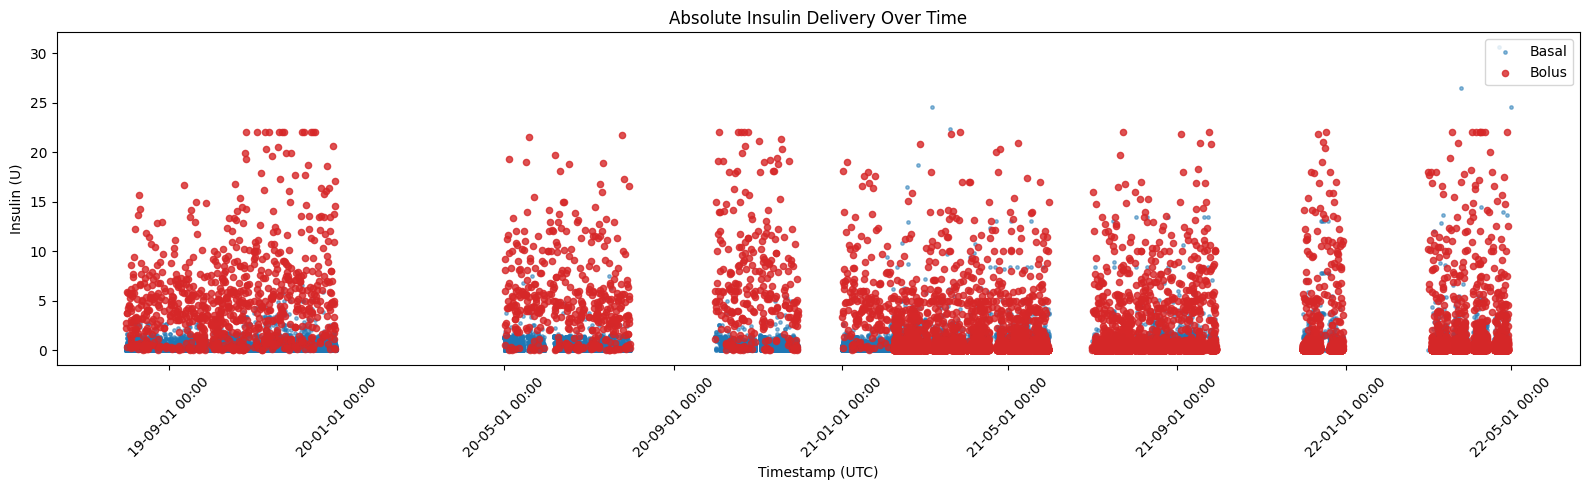

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use normalized combined schema: date/type/value/deliveryReason
plot_df = df[df["type"] == "insulin"].copy()
plot_df["dt"] = plot_df["date"]

bolus_df = plot_df[plot_df["deliveryReason"] == "bolus"]
basal_df = plot_df[plot_df["deliveryReason"] == "basal"]

fig, ax = plt.subplots(figsize=(16, 5))

# Basal insulin as smaller blue points
ax.scatter(basal_df["dt"], basal_df["value"], s=6, color="tab:blue", alpha=0.5, label="Basal")

# Bolus insulin as larger red points
ax.scatter(bolus_df["dt"], bolus_df["value"], s=20, color="tab:red", alpha=0.8, label="Bolus", zorder=5)

ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Insulin (U)")
ax.set_title("Absolute Insulin Delivery Over Time")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%y-%m-%d %H:%M", tz=ZoneInfo("UTC")))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()